Found 2000 files belonging to 3 classes.
Using 1400 files for training.
Found 2000 files belonging to 3 classes.
Using 600 files for validation.
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6852 - loss: 0.8939
Test Accuracy: 0.70
Test Loss: 0.82
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


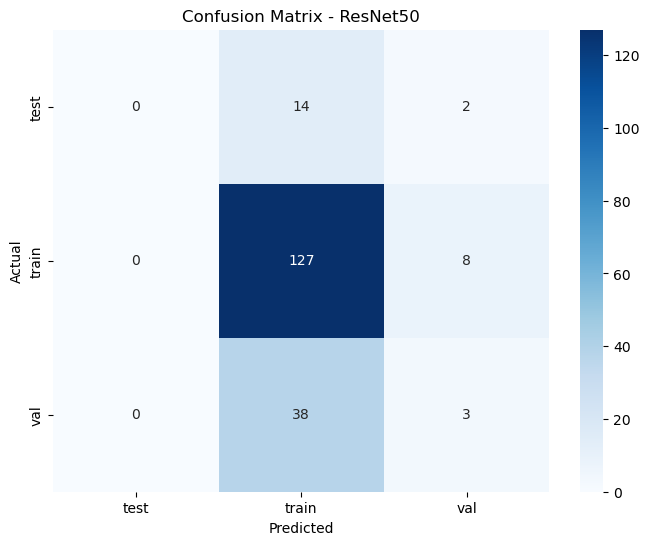

Classification Report:
              precision    recall  f1-score   support

        test       0.00      0.00      0.00        16
       train       0.71      0.94      0.81       135
         val       0.23      0.07      0.11        41

    accuracy                           0.68       192
   macro avg       0.31      0.34      0.31       192
weighted avg       0.55      0.68      0.59       192



c:\Users\kangg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kangg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kangg\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


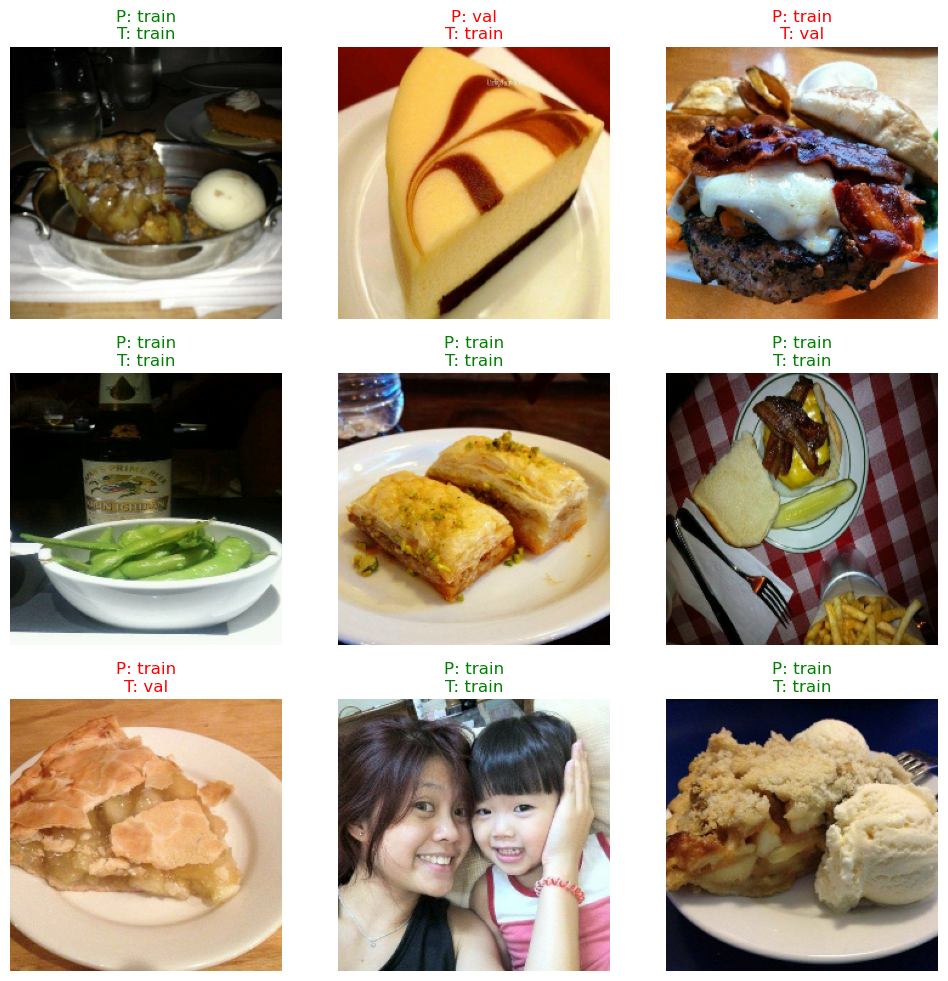

In [3]:
# 06_evaluation.ipynb

import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load model terbaik
model = tf.keras.models.load_model("../backend/app/saved_models/resnet50.h5")

dataset_dir = "../dataset/Food-20"

img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Dari val_ds (30%), kamu bisa split lagi jadi val (20%) + test (10%)
val_batches = tf.data.experimental.cardinality(val_ds)
test_size = val_batches // 3  # kira-kira sepertiga jadi test

test_ds = val_ds.take(test_size)
val_ds = val_ds.skip(test_size)

# 2. Evaluasi model di test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test Loss: {test_loss:.2f}")

# 3. Ambil label sebenarnya dan prediksi
y_true = []
y_pred = []

class_names = train_ds.class_names

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# 5. Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 6. Visualisasi beberapa prediksi
plt.figure(figsize=(12, 12))
for images, labels in test_ds.take(1):  # ambil 1 batch
    preds = model.predict(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_label = class_names[np.argmax(preds[i])]
        true_label = class_names[labels[i]]
        color = "green" if pred_label == true_label else "red"
        plt.title(f"P: {pred_label}\nT: {true_label}", color=color)
        plt.axis("off")
plt.show()